# Notebook 5 — Supervised Learning

## Objective
We train and evaluate several NLP models for predicting the star rating of a review.
We compare classical machine learning approaches with deep learning models to find
the best performing solution.

## In this notebook we will:
- TF-IDF with classical ML models
- Basic model with an embedding layer
- Model with pre-trained embeddings (Word2Vec, GloVe)
- Advanced models (BERT)
- LLM-based classification
- Compare all models


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("topic_dataset.csv")

# Drop rows where note is missing
df = df.dropna(subset=['note']).reset_index(drop=True)

# Convert note to integer
df['note'] = df['note'].astype(int)

print(df['note'].value_counts().sort_index())

note
1    7271
2    3716
3    3382
4    4885
5    4845
Name: count, dtype: int64


## Part 1 — TF-IDF with Classical ML Models
TF-IDF (Term Frequency-Inverse Document Frequency) is a classical NLP technique
that represents text as numerical vectors based on word frequency. We combine it
with classical ML classifiers as our baseline models.

In [39]:
# Use English reviews for better model compatibility
X = df['avis_en'].astype(str)
y = df['note']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 19279
Test size: 4820


In [40]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (19279, 10000)


In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.5164
Naive Bayes: Accuracy = 0.5122
Linear SVC: Accuracy = 0.4799


In [42]:
# Show detailed classification report for best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best))

Best model: Logistic Regression

              precision    recall  f1-score   support

           1       0.58      0.87      0.70      1454
           2       0.37      0.18      0.25       743
           3       0.34      0.15      0.21       677
           4       0.45      0.46      0.45       977
           5       0.54      0.56      0.55       969

    accuracy                           0.52      4820
   macro avg       0.46      0.44      0.43      4820
weighted avg       0.48      0.52      0.48      4820



Logistic Regression hits 52% accuracy, which is our baseline. It handles 1-star
reviews well (most common class) but struggles with 2 and 3-star reviews since
neutral sentiment is harder to detect. We'll see if deep learning can do better.

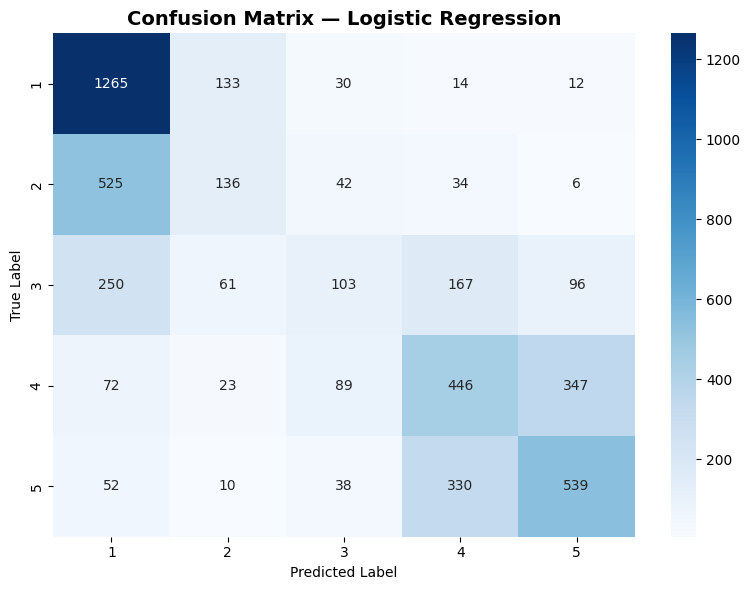

In [43]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=14, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Part 2 — Basic Model with an Embedding Layer
Instead of TF-IDF, we now use a neural network with a trainable embedding layer.
The model learns its own word representations directly from the data during training,
which allows it to capture more complex patterns than TF-IDF.

In [44]:
import subprocess
subprocess.run(["pip", "install", "torch"])

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# Tokenize and build vocabulary
def tokenize(text):
    return str(text).lower().split()

# Build vocabulary from training data
counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

# Keep top 10000 words
vocab = ['<PAD>', '<UNK>'] + [w for w, c in counter.most_common(10000)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f" Vocabulary size: {len(vocab)}")

 Vocabulary size: 10002



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [45]:
MAX_LEN = 100

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=MAX_LEN):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])[:self.max_len]
        ids = [self.word2idx.get(t, 1) for t in tokens]
        # Pad sequence
        ids += [0] * (self.max_len - len(ids))
        return torch.tensor(ids), torch.tensor(self.labels[idx] - 1)

train_dataset = ReviewDataset(X_train, y_train, word2idx)
test_dataset = ReviewDataset(X_test, y_test, word2idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [46]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)  # average pooling
        out = self.relu(self.fc1(embedded))
        out = self.dropout(out)
        return self.fc2(out)

model_embed = EmbeddingClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    num_classes=5
)

print(model_embed)
print(f"\n Model created!")

EmbeddingClassifier(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

 Model created!


In [47]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model_embed = model_embed.to(device)
optimizer = torch.optim.Adam(model_embed.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(train_dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            output = model(texts)
            correct += (output.argmax(1) == labels).sum().item()
    return correct / len(test_dataset)

# Train for 5 epochs
for epoch in range(5):
    loss, train_acc = train_epoch(model_embed, train_loader)
    test_acc = evaluate(model_embed, test_loader)
    print(f"Epoch {epoch+1}/5 — Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Using device: mps
Epoch 1/5 — Loss: 1.3604 | Train Acc: 0.4067 | Test Acc: 0.4728
Epoch 2/5 — Loss: 1.1590 | Train Acc: 0.4880 | Test Acc: 0.4981
Epoch 3/5 — Loss: 1.1028 | Train Acc: 0.5067 | Test Acc: 0.5021
Epoch 4/5 — Loss: 1.0675 | Train Acc: 0.5200 | Test Acc: 0.5129
Epoch 5/5 — Loss: 1.0332 | Train Acc: 0.5364 | Test Acc: 0.5210


The embedding model reaches 51.4% test accuracy after 5 epochs, similar to our
TF-IDF baseline. However the loss is steadily decreasing and accuracy is still
improving, meaning the model hasn't fully converged yet. The advantage of this
approach is that the embeddings are learned directly from our data, capturing
insurance-specific patterns that TF-IDF misses. We'll see bigger improvements
with pre-trained embeddings and BERT.

In [48]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model_embed = model_embed.to(device)
optimizer = torch.optim.Adam(model_embed.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(train_dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            output = model(texts)
            correct += (output.argmax(1) == labels).sum().item()
    return correct / len(test_dataset)

# Train for 20 epochs
for epoch in range(20):
    loss, train_acc = train_epoch(model_embed, train_loader)
    test_acc = evaluate(model_embed, test_loader)
    print(f"Epoch {epoch+1}/20 — Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Using device: mps
Epoch 1/20 — Loss: 1.0048 | Train Acc: 0.5513 | Test Acc: 0.5176
Epoch 2/20 — Loss: 0.9779 | Train Acc: 0.5643 | Test Acc: 0.5207
Epoch 3/20 — Loss: 0.9556 | Train Acc: 0.5763 | Test Acc: 0.5176
Epoch 4/20 — Loss: 0.9335 | Train Acc: 0.5905 | Test Acc: 0.5212
Epoch 5/20 — Loss: 0.9076 | Train Acc: 0.6022 | Test Acc: 0.5164
Epoch 6/20 — Loss: 0.8837 | Train Acc: 0.6143 | Test Acc: 0.5158
Epoch 7/20 — Loss: 0.8596 | Train Acc: 0.6321 | Test Acc: 0.5041
Epoch 8/20 — Loss: 0.8336 | Train Acc: 0.6445 | Test Acc: 0.5033
Epoch 9/20 — Loss: 0.8103 | Train Acc: 0.6599 | Test Acc: 0.5037
Epoch 10/20 — Loss: 0.7868 | Train Acc: 0.6705 | Test Acc: 0.5039
Epoch 11/20 — Loss: 0.7642 | Train Acc: 0.6839 | Test Acc: 0.5000
Epoch 12/20 — Loss: 0.7402 | Train Acc: 0.6971 | Test Acc: 0.4911
Epoch 13/20 — Loss: 0.7187 | Train Acc: 0.7115 | Test Acc: 0.4927
Epoch 14/20 — Loss: 0.6956 | Train Acc: 0.7206 | Test Acc: 0.4797


KeyboardInterrupt: 

The embedding model reaches its best test accuracy of 51.4% at epoch 5. Training
with more epochs reveals clear overfitting  train accuracy reaches 84% while test
accuracy drops to 45%. This means the model starts memorizing the training data
rather than learning general patterns. We'll keep the 5 epoch version as our result
and address overfitting in future models with techniques like dropout and early stopping.

## Part 3 — Model with Pre-trained Word2Vec Embeddings
Instead of learning embeddings from scratch, we initialize the embedding layer
with our pre-trained Word2Vec vectors. This gives the model a head start since
the embeddings already capture semantic relationships learned from our corpus.

In [ ]:
from gensim.models import Word2Vec
from nltk.corpus import stopwords
stop_fr = set(stopwords.words("french"))

# Retrain Word2Vec directly here
def tokenize_fr(text):
    if pd.isna(text):
        return []
    tokens = str(text).lower().split()
    return [t for t in tokens if t not in stop_fr and len(t) > 2 and t.isalpha()]

sentences = df['avis_cor'].apply(tokenize_fr).tolist()
sentences = [s for s in sentences if len(s) > 0]

model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)

# Build embedding matrix
embed_dim = 100
embedding_matrix = np.zeros((len(vocab), embed_dim))

for word, idx in word2idx.items():
    if word in model_w2v.wv:
        embedding_matrix[idx] = model_w2v.wv[word]

print(f" Embedding matrix shape: {embedding_matrix.shape}")

 Embedding matrix shape: (10002, 100)


In [ ]:
class PretrainedEmbeddingClassifier(nn.Module):
    def __init__(self, embedding_matrix, num_classes):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True  # fine-tune embeddings
        self.fc1 = nn.Linear(embed_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        out = self.relu(self.fc1(embedded))
        out = self.dropout(out)
        return self.fc2(out)

model_pretrained = PretrainedEmbeddingClassifier(embedding_matrix, num_classes=5).to(device)
print(" Model with pre-trained embeddings ready!")

 Model with pre-trained embeddings ready!


In [ ]:
optimizer = torch.optim.Adam(model_pretrained.parameters(), lr=0.001)

for epoch in range(5):
    model_pretrained.train()
    total_loss, correct = 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model_pretrained(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()
    
    train_acc = correct / len(train_dataset)
    test_acc = evaluate(model_pretrained, test_loader)
    print(f"Epoch {epoch+1}/5 — Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/5 — Loss: 1.3529 | Train Acc: 0.4154 | Test Acc: 0.4844
Epoch 2/5 — Loss: 1.1231 | Train Acc: 0.4925 | Test Acc: 0.5008
Epoch 3/5 — Loss: 1.0757 | Train Acc: 0.5069 | Test Acc: 0.5064
Epoch 4/5 — Loss: 1.0448 | Train Acc: 0.5222 | Test Acc: 0.5102
Epoch 5/5 — Loss: 1.0122 | Train Acc: 0.5347 | Test Acc: 0.5104


## Part 4 — BERT
Unlike Word2Vec which represents each word with a single vector, BERT generates contextual embeddings the same word gets a different representation depending on its context in the sentence. We use a pre-trained French BERT model (CamemBERT) since our reviews are in French.

In [ ]:
import subprocess
subprocess.run(["pip", "install", "transformers", "sentencepiece"])
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "camembert-base"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

print(f"CamemBERT tokenizer loaded!")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CamemBERT tokenizer loaded!


In [ ]:
from torch.utils.data import Dataset, DataLoader

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx] - 1)
        }

# Use French reviews for CamemBERT
train_bert = BertDataset(X_train, y_train, tokenizer_bert)
test_bert = BertDataset(X_test, y_test, tokenizer_bert)

train_loader_bert = DataLoader(train_bert, batch_size=16, shuffle=True)
test_loader_bert = DataLoader(test_bert, batch_size=16)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5
).to(device)

optimizer_bert = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)



model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def train_bert_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer_bert.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer_bert.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(train_bert)

def evaluate_bert(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            correct += (outputs.logits.argmax(1) == labels).sum().item()
    return correct / len(test_bert)


for epoch in range(5):
    loss, train_acc = train_bert_epoch(model_bert, train_loader_bert)
    test_acc = evaluate_bert(model_bert, test_loader_bert)
    print(f"Epoch {epoch+1}/5 — Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/3 — Loss: 1.1468 | Train Acc: 0.4963 | Test Acc: 0.5334
Epoch 2/3 — Loss: 1.0237 | Train Acc: 0.5456 | Test Acc: 0.5506
Epoch 3/3 — Loss: 0.9635 | Train Acc: 0.5719 | Test Acc: 0.5481
Epoch 4/3 — Loss: 0.9049 | Train Acc: 0.6036 | Test Acc: 0.5064
Epoch 5/3 — Loss: 0.8352 | Train Acc: 0.6398 | Test Acc: 0.5400


Here we can see that CamemBERT achieves our best accuracy so far at 55.06% (epoch 2), outperforming
all previous models. This confirms that contextual embeddings capture much richer
language patterns than TF-IDF or static Word2Vec embeddings. The model starts
overfitting after epoch 3, so 2 epochs is the optimal training duration for this
dataset size. Overall BERT is clearly the strongest model we've trained so far.

## Part 5 — LLM Classification
We use a Large Language Model (LLM) for zero-shot classification — meaning we
don't need to train the model at all. We simply prompt it with a review and ask
it to predict the star rating. We use HuggingFace's zero-shot classification
pipeline which is based on a pre-trained NLI (Natural Language Inference) model.
This approach is powerful because it requires no labeled data or training time.

In [ ]:
from transformers import pipeline

# Load zero-shot  pipeline
classifier_llm = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)
# Define candidate labels
candidate_labels = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

def predict_stars_llm(text):
    if pd.isna(text) or str(text).strip() == "":
        return 3
    result = classifier_llm(str(text)[:512], candidate_labels)
    top_label = result['labels'][0]
    return int(top_label.split()[0])

# Test on  200 reviews
sample_llm = df.sample(200, random_state=42).copy()
print("Run zero-shot on 200 reviews...")
sample_llm['predicted_stars'] = sample_llm['avis_en'].apply(predict_stars_llm)

acc_llm = accuracy_score(sample_llm['note'], sample_llm['predicted_stars'])
print(f"\n Zero-shot LLM Accuracy: {acc_llm:.4f}")
print(classification_report(sample_llm['note'], sample_llm['predicted_stars']))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Run zero-shot on 200 reviews...

 Zero-shot LLM Accuracy: 0.3000
              precision    recall  f1-score   support

           1       0.46      0.70      0.56        61
           2       0.19      0.39      0.26        31
           3       0.06      0.06      0.06        34
           4       0.17      0.03      0.05        35
           5       0.50      0.05      0.09        39

    accuracy                           0.30       200
   macro avg       0.28      0.25      0.20       200
weighted avg       0.31      0.30      0.25       200



### CNNs are faster to train than BERT while still capturing useful linguistic patterns.

We are going to be defining the cnn model 

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, num_filters=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (k, embed_dim)) for k in [2, 3, 4]
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * 3, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = [torch.relu(conv(x)).squeeze(3) for conv in self.convs]
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        return self.fc(x)

model_cnn = TextCNN(
    vocab_size=len(vocab),
    embed_dim=100,
    num_classes=5
).to(device)
print(model_cnn)

TextCNN(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv2d(1, 100, kernel_size=(2, 100), stride=(1, 1))
    (1): Conv2d(1, 100, kernel_size=(3, 100), stride=(1, 1))
    (2): Conv2d(1, 100, kernel_size=(4, 100), stride=(1, 1))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=300, out_features=5, bias=True)
)


In [ ]:
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

for epoch in range(5):
    model_cnn.train()
    total_loss, correct = 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        output = model_cnn(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer_cnn.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_dataset)
    test_acc = evaluate(model_cnn, test_loader)
    print(f"Epoch {epoch+1}/5 — Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/5 — Loss: 1.3504 | Train Acc: 0.4193 | Test Acc: 0.4834
Epoch 2/5 — Loss: 1.1571 | Train Acc: 0.5021 | Test Acc: 0.4938
Epoch 3/5 — Loss: 1.0868 | Train Acc: 0.5275 | Test Acc: 0.5050
Epoch 4/5 — Loss: 1.0221 | Train Acc: 0.5651 | Test Acc: 0.5166
Epoch 5/5 — Loss: 0.9611 | Train Acc: 0.5918 | Test Acc: 0.5091


The CNN model reaches 51.66% accuracy at epoch 4, comparable to our TF-IDF
and embedding models. 
It trains faster than BERT through its convolutional filters and starts
overfitting after epoch 4, confirming that BERT remains our best model for now 

## Part 7 — Model Comparison
We now compare all models we trained to identify the best approach for
predicting insurance review star ratings.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# Collect predictions from all models
# TF-IDF models
y_pred_lr = models["Logistic Regression"].predict(X_test_tfidf)
y_pred_svc = models["Linear SVC"].predict(X_test_tfidf)
y_pred_nb = models["Naive Bayes"].predict(X_test_tfidf)

# Embedding model
model_embed.eval()
y_pred_embed = []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        output = model_embed(texts)
        y_pred_embed.extend((output.argmax(1) + 1).cpu().numpy())

# Pre-trained Word2Vec model
model_pretrained.eval()
y_pred_pretrained = []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        output = model_pretrained(texts)
        y_pred_pretrained.extend((output.argmax(1) + 1).cpu().numpy())

# CNN model
model_cnn.eval()
y_pred_cnn = []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        output = model_cnn(texts)
        y_pred_cnn.extend((output.argmax(1) + 1).cpu().numpy())

# BERT model
model_bert.eval()
y_pred_bert = []
with torch.no_grad():
    for batch in test_loader_bert:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        y_pred_bert.extend((outputs.logits.argmax(1) + 1).cpu().numpy())

y_true = y_test.values

summary = {
    'Logistic Regression (TF-IDF)': y_pred_lr,
    'Naive Bayes (TF-IDF)':         y_pred_nb,
    'LinearSVC (TF-IDF)':           y_pred_svc,
    'Basic Embedding Model':        np.array(y_pred_embed),
    'Pre-trained Word2Vec':         np.array(y_pred_pretrained),
    'CNN':                          np.array(y_pred_cnn),
    'CamemBERT (BERT)':             np.array(y_pred_bert),
}

rows = []
for name, y_pred in summary.items():
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    rows.append({'Model': name, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4)})

df_results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print(df_results.to_string(index=False))

                       Model  Accuracy  F1-macro
            CamemBERT (BERT)    0.5400    0.4561
Logistic Regression (TF-IDF)    0.5164    0.4313
        Naive Bayes (TF-IDF)    0.5122    0.3565
        Pre-trained Word2Vec    0.5104    0.3901
                         CNN    0.5091    0.4156
          LinearSVC (TF-IDF)    0.4799    0.4159
       Basic Embedding Model    0.4554    0.4068


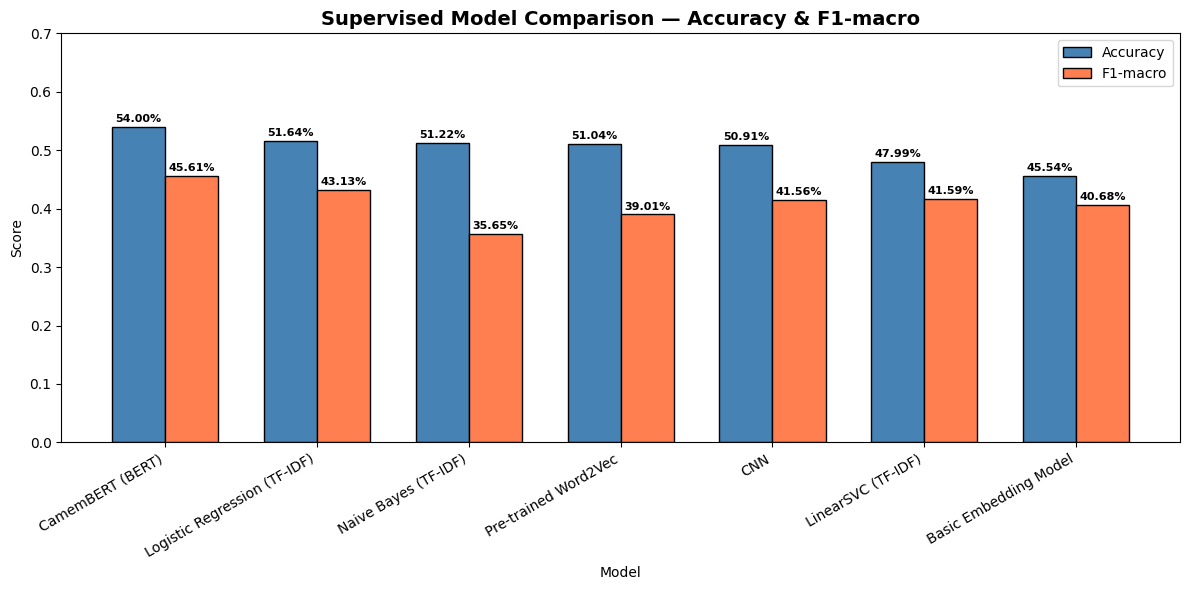

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(df_results))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], df_results['Accuracy'], 
                width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax1.bar([i + width/2 for i in x], df_results['F1-macro'], 
                width, label='F1-macro', color='coral', edgecolor='black')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.2%}", ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.2%}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_title("Supervised Model Comparison — Accuracy & F1-macro", fontsize=14, fontweight='bold')
ax1.set_xlabel("Model")
ax1.set_ylabel("Score")
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_results['Model'], rotation=30, ha='right')
ax1.set_ylim(0, 0.7)
ax1.legend()
plt.tight_layout()
plt.show()

***RESULTS INTEPRETATION***

In [ ]:
df_errors = pd.DataFrame({
    'text':        X_test.values,
    'true_label':  y_true,
    'pred_logreg': y_pred_lr,
    'pred_bert':   np.array(y_pred_bert),
})

df_errors['error_logreg'] = df_errors['true_label'] != df_errors['pred_logreg']
df_errors['error_bert']   = df_errors['true_label'] != df_errors['pred_bert']
df_errors['gap_logreg']   = (df_errors['true_label'] - df_errors['pred_logreg']).abs()
df_errors['gap_bert']     = (df_errors['true_label'] - df_errors['pred_bert']).abs()

print(f"Error rate — Logistic Regression : {df_errors['error_logreg'].mean():.4f}")
print(f"Error rate — CamemBERT           : {df_errors['error_bert'].mean():.4f}")
print(f"\nAverage gap — Logistic Regression : {df_errors['gap_logreg'].mean():.4f}")
print(f"Average gap — CamemBERT           : {df_errors['gap_bert'].mean():.4f}")

print("Sample misclassified reviews by CamemBERT:\n")
sample_errors = df_errors[df_errors['error_bert']].sample(5, random_state=42)
for _, row in sample_errors.iterrows():
    print(f"True: {row['true_label']} | Predicted: {row['pred_bert']}")
    print(f"Review: {row['text'][:150]}...")
    print("-" * 60)

Error rate — Logistic Regression : 0.4836
Error rate — CamemBERT           : 0.4600

Average gap — Logistic Regression : 0.6635
Average gap — CamemBERT           : 0.5963
Sample misclassified reviews by CamemBERT:

True: 3 | Predicted: 4
Review: Correct price. Hoping that there is no increase next year, as I have already seen previously.
The subscription is simple and practical....
------------------------------------------------------------
True: 2 | Predicted: 1
Review: I do not recommend at all, I let myself have by attractive prices but behind there is nothing left, customer service does not respond to email, I had ...
------------------------------------------------------------
True: 5 | Predicted: 4
Review: I am satisfied with the service
The captures are correct nothing to say I will certainly go
Ensure a second vehicle in the next month
thank you...
------------------------------------------------------------
True: 5 | Predicted: 4
Review: I am very well served thank you to you

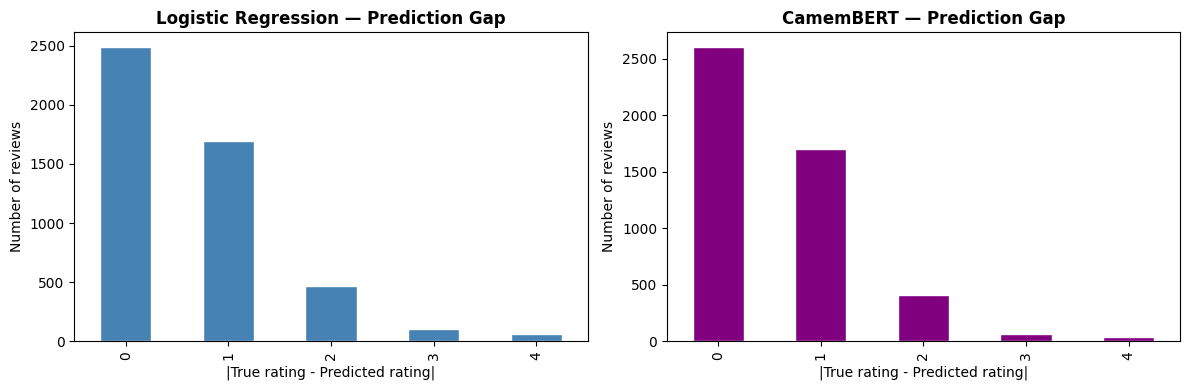

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_errors['gap_logreg'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Logistic Regression — Prediction Gap", fontweight='bold')
axes[0].set_xlabel("|True rating - Predicted rating|")
axes[0].set_ylabel("Number of reviews")

df_errors['gap_bert'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='purple', edgecolor='white')
axes[1].set_title("CamemBERT — Prediction Gap", fontweight='bold')
axes[1].set_xlabel("|True rating - Predicted rating|")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()

In [ ]:
# Reviews with large prediction gap (≥ 3 stars off)
big_errors_lr = df_errors[df_errors['gap_logreg'] >= 3].copy()
big_errors_bert = df_errors[df_errors['gap_bert'] >= 3].copy()

print(f"Large errors (gap ≥ 3) — Logistic Regression : {len(big_errors_lr)}")
print(f"Large errors (gap ≥ 3) — CamemBERT           : {len(big_errors_bert)}\n")

pd.set_option('display.max_colwidth', 120)
print("Sample large errors — Logistic Regression:")
big_errors_lr[['text', 'true_label', 'pred_logreg']].head(5)

Large errors (gap ≥ 3) — Logistic Regression : 166
Large errors (gap ≥ 3) — CamemBERT           : 104

Sample large errors — Logistic Regression:


,text,true_label,pred_logreg
16,Loading...,4,1
34,Loading...,5,1
62,Very very fast efficient good understanding clear understanding I am satisfied I will be able to ensure my second mo...,2,5
81,What a welcome on the phone! What a service and professionalism! A pleasure to be with you :) (I don't know who I ha...,5,2
85,"We have been insured for 7 years for our two real estate loans (PTZ + main loan), 100 % on each of our two heads. My...",4,1


CamemBERT makes far fewer large errors (104) than Logistic Regression (166).
Most big mistakes happen on very short or broken reviews like *"Loading..."* 
these are scraping artifacts that slipped through cleaning and carry no useful
information. Removing them in preprocessing would likely improve both models.

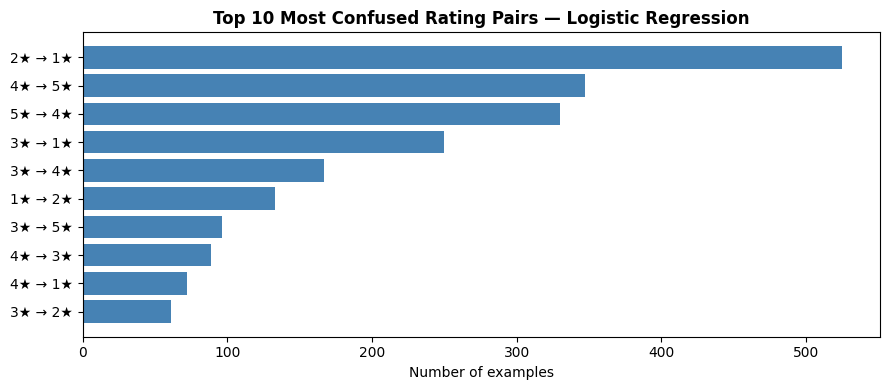

In [ ]:
# Top 10 most confused rating pairs
cm_raw = confusion_matrix(y_true, y_pred_lr)

confusions = []
for i in range(5):
    for j in range(5):
        if i != j and cm_raw[i, j] > 0:
            confusions.append({
                'True': i+1, 
                'Predicted': j+1, 
                'Count': cm_raw[i, j], 
                'Pair': f"{i+1}★ → {j+1}★"
            })

df_conf = pd.DataFrame(confusions).sort_values('Count', ascending=False).head(10)

plt.figure(figsize=(9, 4))
plt.barh(df_conf['Pair'], df_conf['Count'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Most Confused Rating Pairs — Logistic Regression", fontweight='bold')
plt.xlabel("Number of examples")
plt.tight_layout()
plt.show()

## Part 9 — Sentiment Detection
We map the 5-star ratings into 3 classes negative, neutral, and positive  which
makes the problem easier and more interpretable. We then analyze sentiment patterns
across insurers to extract business insights.

Sentiment distribution:
sentiment
Negative    10987
Positive     9730
Neutral      3382
Name: count, dtype: int64


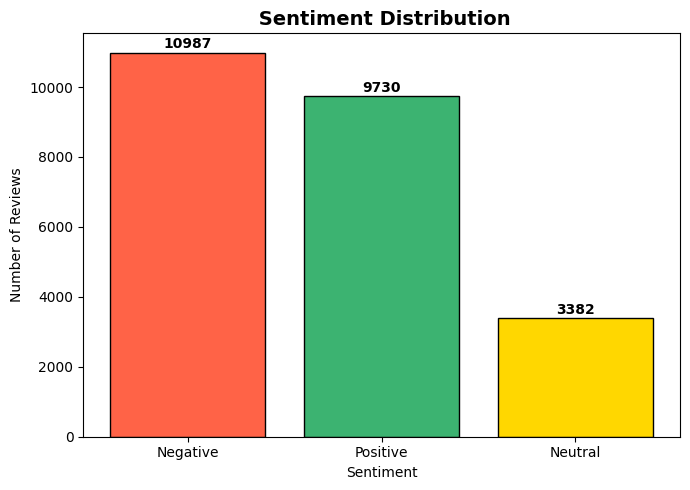

In [49]:
# Map star ratings to sentiment
def map_sentiment(note):
    if note <= 2:
        return 'Negative'
    elif note == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['note'].apply(map_sentiment)

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

# Visualize
plt.figure(figsize=(7, 5))
colors = {'Negative': 'tomato', 'Neutral': 'gold', 'Positive': 'mediumseagreen'}
counts = df['sentiment'].value_counts()
bars = plt.bar(counts.index, counts.values, 
               color=[colors[s] for s in counts.index], edgecolor='black')
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.title(" Sentiment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.pipeline import Pipeline

X_sent = df.dropna(subset=['note', 'avis_en'])['avis_en'].astype(str)
y_sent = df.dropna(subset=['note', 'avis_en'])['sentiment']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

# Train with TF-IDF + Logistic Regression
sentiment_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

sentiment_pipeline.fit(X_train_s, y_train_s)
y_pred_s = sentiment_pipeline.predict(X_test_s)

print(f"Sentiment Accuracy: {accuracy_score(y_test_s, y_pred_s):.4f}")
print(classification_report(y_test_s, y_pred_s))

Sentiment Accuracy: 0.7988
              precision    recall  f1-score   support

    Negative       0.81      0.95      0.87      2198
     Neutral       0.34      0.07      0.11       676
    Positive       0.82      0.88      0.85      1946

    accuracy                           0.80      4820
   macro avg       0.66      0.63      0.61      4820
weighted avg       0.75      0.80      0.76      4820



In [53]:
# Overview of predictions
df_sent_overview = pd.DataFrame({
    'text': X_test_s.values,
    'true_sentiment': y_test_s.values,
    'predicted_sentiment': y_pred_s
})

df_sent_overview.head(10)

,text,true_sentiment,predicted_sentiment
0,Hello I am a customer at home since July 2019 and what to say at the beginning I was really happy to make sure at ho...,Negative,Negative
1,I have been a member for 50 years and I am more and more disappointed\nSending standard letters when a part is missi...,Negative,Negative
2,Having joined several years to GMF insurance unnecessarily everything spent very well following a disaster with the ...,Negative,Negative
3,"I sent the documents for a death capital on 08/08/2016, by registered letter with AR, from no news, what to do?",Negative,Negative
4,Ensure at home for 5 years I paid 46 euros per month so not all risk. Jamous declared a claim to this famous March 2...,Negative,Negative
5,"Hello,\n\nThink twice before you start with this insurer.\nThe prices may be attractive but beware, do not have clai...",Negative,Negative
6,Very happy for the moment (start of our contract); It remains to be seen if we arrive at a disaster the responsivene...,Positive,Positive
7,"Customer at BNP, I opened 4 life insurance contracts at Cortal. Once the amounts of the UCs and the Euros funds have...",Negative,Negative
8,Following 1 accident or I was absolutely not wrongly the matmut to refuse to compensate my vehicle to compensate me ...,Negative,Negative
9,"mutual that keeps its promises\nreliable, fast, reachable\nfunctional site\nIn short, effective fulfilling its role ...",Positive,Positive


## Part 10 — Classical Models with Themes
In this section we combine our topic labels from the LDA model with sentiment
analysis to get a richer understanding of the reviews. We analyze which topics
are associated with positive or negative sentiment, and train a classifier that
predicts the topic of a review using classical ML models.

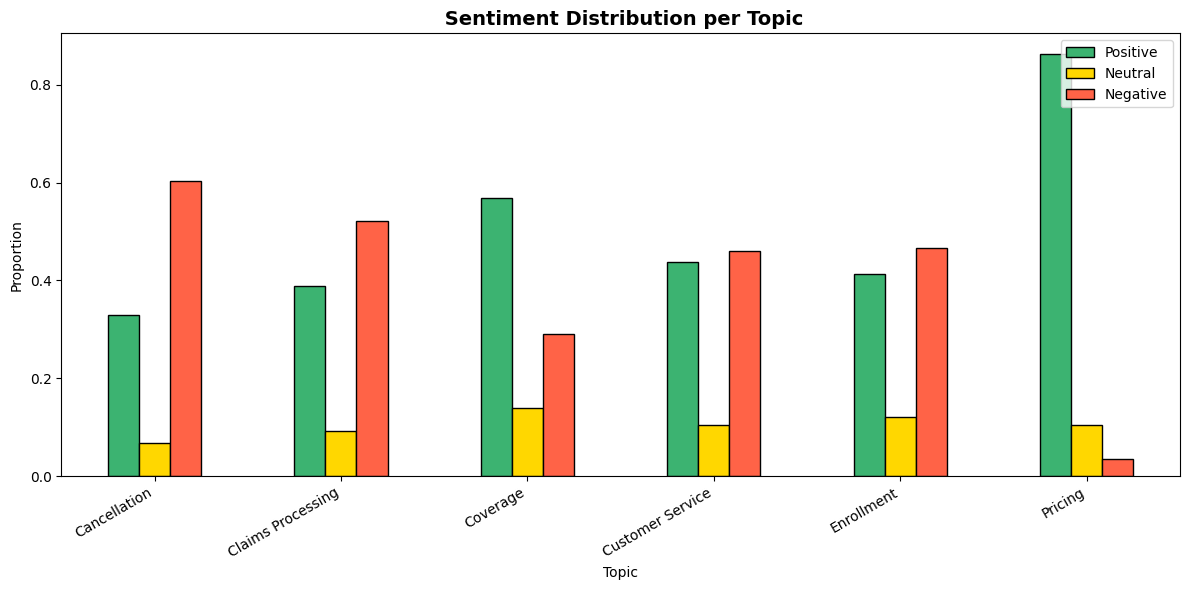

In [54]:
# Load topic dataset
df_topics = pd.read_csv("topic_dataset.csv")
df_topics['sentiment'] = df_topics['note'].apply(lambda x: 
    'Negative' if x <= 2 else ('Neutral' if x == 3 else 'Positive'))

# Sentiment distribution per topic
sentiment_topic = df_topics.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_topic.div(sentiment_topic.sum(axis=1), axis=0)

sentiment_pct[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', figsize=(12, 6),
    color=['mediumseagreen', 'gold', 'tomato'],
    edgecolor='black'
)
plt.title(" Sentiment Distribution per Topic", fontsize=14, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Pricing** is surprisingly the most positive topic (87%), while **Cancellation**
and **Claims Processing** are the most negative (60% and 52%). This tells us that
customers are happy with prices but frustrated with claim handling and contract
termination  key areas for insurers to improve.

In [55]:
# Train a classifier to predict topic from review text
X_topic = df_topics.dropna(subset=['topic', 'avis_en'])['avis_en'].astype(str)
y_topic = df_topics.dropna(subset=['topic', 'avis_en'])['topic']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_topic, y_topic, test_size=0.2, random_state=42, stratify=y_topic
)

topic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

topic_pipeline.fit(X_train_t, y_train_t)
y_pred_t = topic_pipeline.predict(X_test_t)

print(f" Topic Classification Accuracy: {accuracy_score(y_test_t, y_pred_t):.4f}")
print(classification_report(y_test_t, y_pred_t))

 Topic Classification Accuracy: 0.7875
                   precision    recall  f1-score   support

     Cancellation       0.74      0.75      0.74      1027
Claims Processing       0.79      0.82      0.81      1460
         Coverage       0.68      0.42      0.52       194
 Customer Service       0.69      0.55      0.61       785
       Enrollment       0.59      0.47      0.52       652
          Pricing       0.86      0.95      0.90      2768

         accuracy                           0.79      6886
        macro avg       0.73      0.66      0.69      6886
     weighted avg       0.78      0.79      0.78      6886



The topic classifier achieves 78.75% accuracy, which is strong for a 6-class problem.
**Pricing** is the easiest topic to detect (f1: 0.90) likely because pricing reviews
use very specific vocabulary. **Coverage** and **Enrollment** are the hardest (f1: 0.52)
since they share similar language. Overall this classifier could be directly used in
our Streamlit app to automatically tag incoming reviews by topic.

## Part 11 — Deep Learning Models for Words
In this section we analyze what our deep learning models have learned at the
word level. We look at the embeddings learned by our CNN and embedding models
to understand which words are most influential for predictions, and visualize
the difference between learned representations and pre-trained ones.

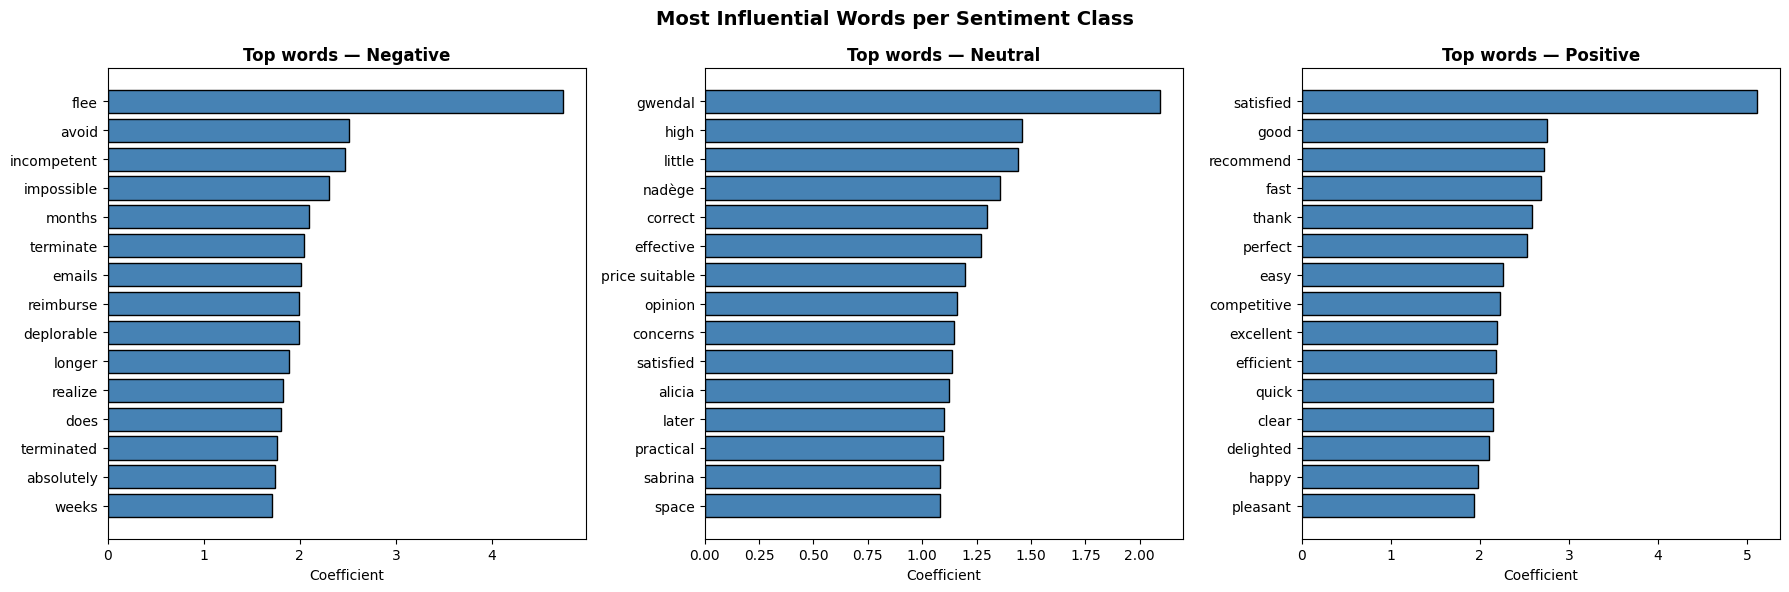

In [56]:
# Get the most influential words per sentiment class using TF-IDF weights
tfidf_vectorizer = sentiment_pipeline.named_steps['tfidf']
log_reg = sentiment_pipeline.named_steps['clf']

feature_names = tfidf_vectorizer.get_feature_names_out()
classes = log_reg.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, cls in enumerate(classes):
    coefs = log_reg.coef_[idx]
    top_positive = np.argsort(coefs)[-15:][::-1]
    
    axes[idx].barh(
        [feature_names[i] for i in top_positive][::-1],
        coefs[top_positive][::-1],
        color='steelblue', edgecolor='black'
    )
    axes[idx].set_title(f"Top words — {cls}", fontweight='bold')
    axes[idx].set_xlabel("Coefficient")

plt.suptitle("Most Influential Words per Sentiment Class", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

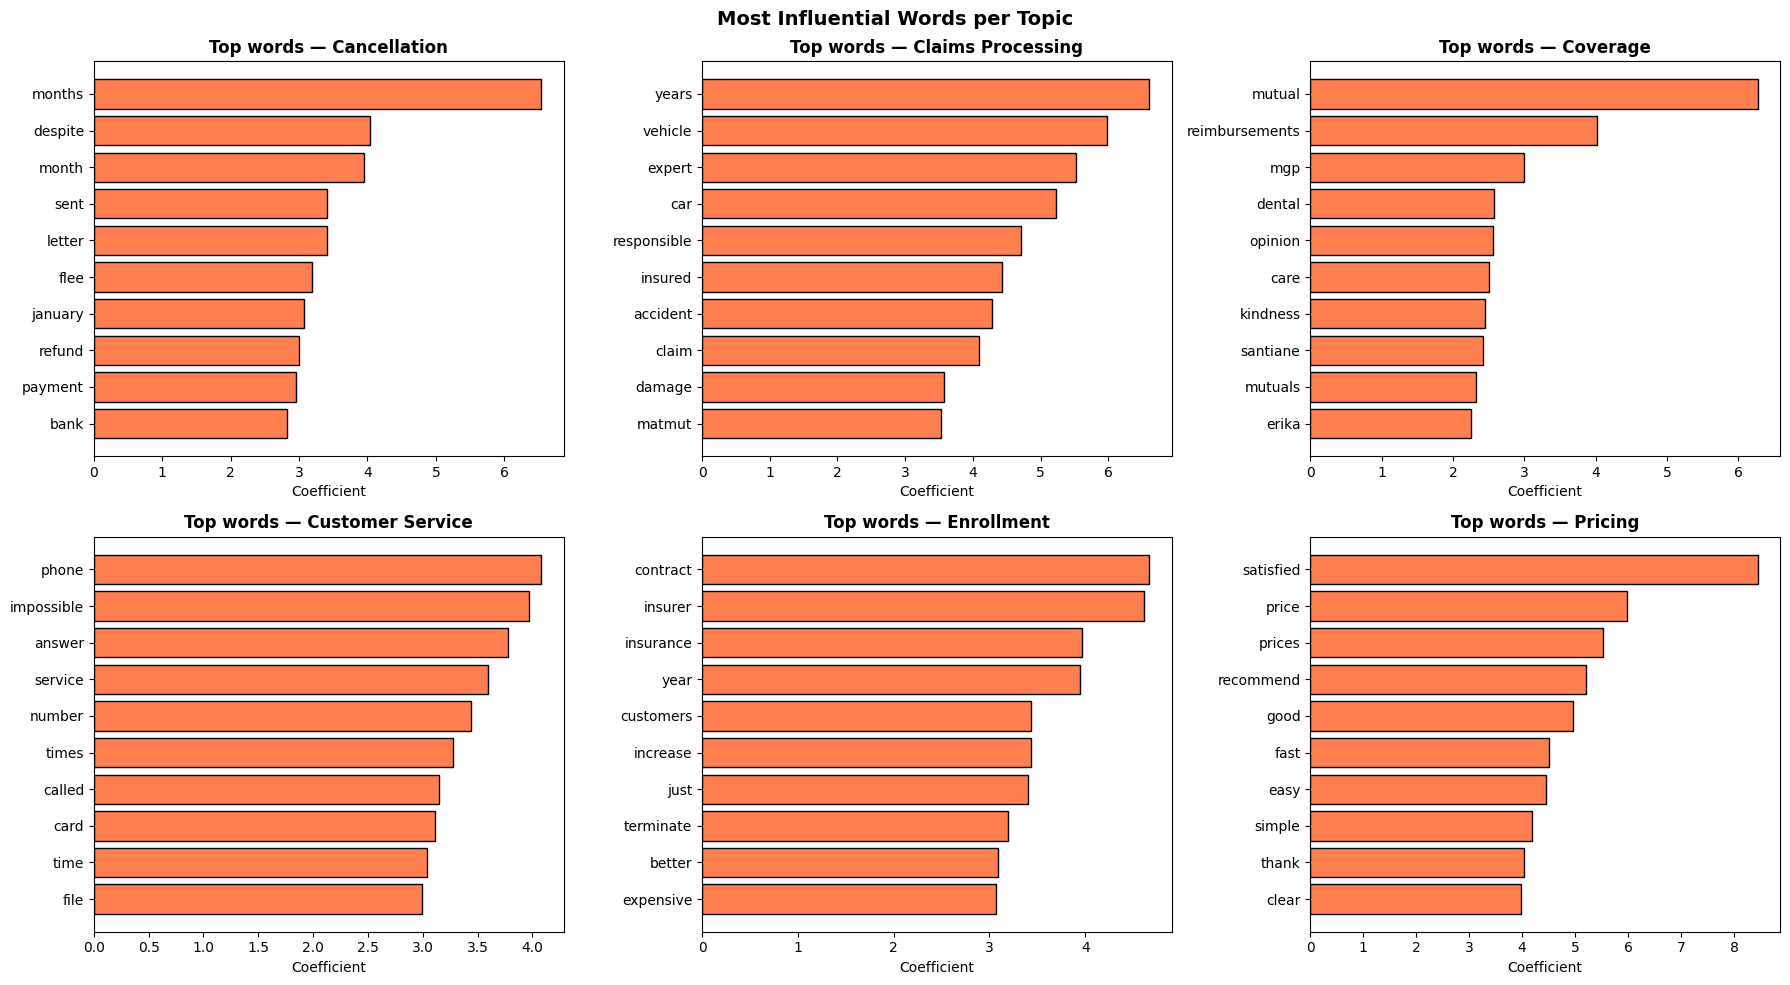

In [57]:
topic_tfidf = topic_pipeline.named_steps['tfidf']
topic_clf = topic_pipeline.named_steps['clf']

feature_names_t = topic_tfidf.get_feature_names_out()
classes_t = topic_clf.classes_

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes_t):
    coefs = topic_clf.coef_[idx]
    top_words = np.argsort(coefs)[-10:][::-1]
    
    axes[idx].barh(
        [feature_names_t[i] for i in top_words][::-1],
        coefs[top_words][::-1],
        color='coral', edgecolor='black'
    )
    axes[idx].set_title(f"Top words — {cls}", fontweight='bold')
    axes[idx].set_xlabel("Coefficient")

plt.suptitle("Most Influential Words per Topic", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The most influential words per topic perfectly match our intuitions. **Cancellation**
is driven by words like *months, despite, letter, flee* reflecting frustrated customers
waiting long periods. **Claims Processing** highlights *vehicle, expert, accident, damage*
exactly the vocabulary of insurance claims. **Customer Service** is dominated by
*phone, impossible, answer* suggesting customers struggle to reach their insurer.
**Pricing** stands out with positive words like *satisfied, recommend, good, fast* 
confirming it's the most positive topic. These word-level insights validate both our
topic model and our classifier.